# BONUS EXERCISE

In [ ]:
from profilers import profile_cpu

In [ ]:
@profile_cpu(interval=1)
def calculate_z_serial_purepython(maxiter, zs, cs):
    """Calculate output list using Julia update rule"""
    output = [0] * len(zs)
    for i in range(len(zs)):
        n = 0
        z = zs[i]
        c = cs[i]
        while abs(z) < 2 and n < maxiter:
            z = z * z + c
            n += 1
        output[i] = n
    return output

When calculate_z_serial_purepython() starts, the profiler:

- Launches a background thread

- Samples CPU usage of each core every 1 second

- While the nested loops iterate over Julia set points:

- The profiler keeps recording how busy each core is

When the function finishes:

- Profiling stops

- CPU usage data is stored and later plotted

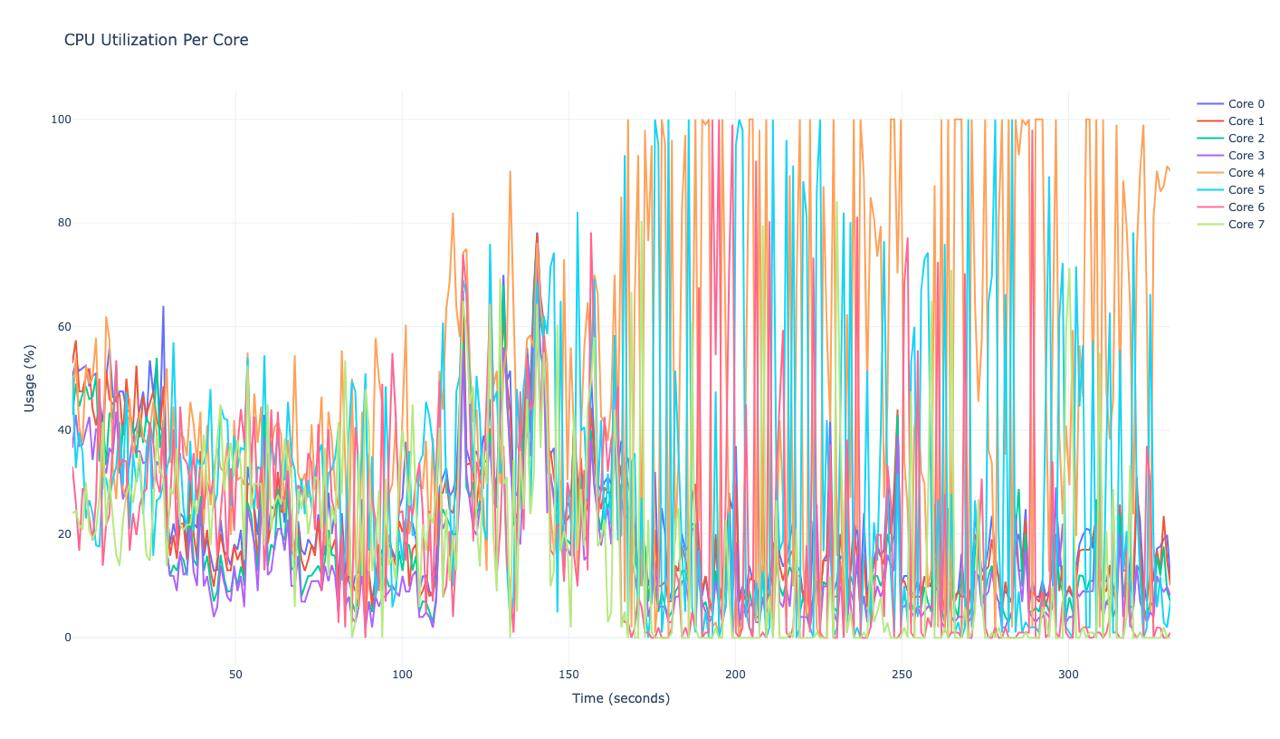

The graph shows that during the Julia set computation, the CPU becomes heavily loaded, with usage frequently spiking close to 100%. Although multiple cores appear active, the workload is dominated by a single long-running Python loop, causing uneven and rapidly fluctuating core usage. This indicates a strongly CPU-bound, mostly single-threaded computation.

### The table shows the summary of the CPU usage


|   Time (s) |   Core 0 |   Core 1 |   Core 2 |   Core 3 |   Core 4 |   Core 5 |   Core 6 |   Core 7 |
|-------------|----------|----------|----------|----------|----------|----------|----------|----------|
|       1.01 |     50.5 |     53   |     43   |     36.6 |     44.6 |     50.5 |     33   |     24   |
|       2.02 |     53   |     57.4 |     49   |     43   |     54   |     32.7 |     26   |     24.5 |
|       3.03 |     51.5 |     47.5 |     44.6 |     37   |     40.6 |     39.6 |     16.8 |     21.8 |
|       4.04 |     52   |     47.5 |     47   |     37.3 |     37.6 |     35.6 |     28.7 |     20.8 |
|       5.05 |     52.5 |     50.5 |     48.5 |     40   |     52.5 |     23   |     28.4 |     30   |
|       6.06 |     48.5 |     52   |     46   |     42.6 |     49   |     26.5 |     23   |     20.6 |
|       7.08 |     50.5 |     44.1 |     46.5 |     34.3 |     50.5 |     24   |     18.8 |     19   |
|       8.09 |     51   |     41   |     50.5 |     40.2 |     57.8 |     17.8 |     26.5 |     20.6 |
|       9.1  |     46   |     45   |     34   |     40   |     38.6 |     17.6 |     50   |     27   |
|      10.11 |     41.2 |     35.6 |     42   |     33.7 |     28.7 |     30.7 |     13.9 |     41.6 |
|      11.12 |     50   |     51.5 |     33.3 |     31.7 |     62   |     30.7 |     21.8 |     21.6 |
|      12.13 |     56   |     46   |     43.4 |     36.6 |     57.4 |     26.7 |     23.8 |     30.7 |
|      13.14 |     46.5 |     45   |     42.2 |     35.4 |     32.7 |     30.7 |     38.6 |     22.8 |
|      14.15 |     45.5 |     46.5 |     52.5 |     43.6 |     26.7 |     33   |     53.5 |     16   |
|      15.16 |     47.5 |     47   |     31.7 |     33.7 |     40.2 |     41.6 |     32.7 |     13.9 |
|      16.17 |     47.5 |     39   |     40.6 |     26.7 |     28.7 |     29.4 |     34.3 |     22.5 |
|      17.19 |     44   |     50   |     42   |     29   |     27   |     47.5 |     34   |     27.7 |
|      18.2  |     43.6 |     43   |     42.6 |     34.3 |     46.1 |     21   |     16.8 |     29.7 |
|      19.2  |     39.4 |     40.4 |     41   |     39   |     35   |     35.3 |     24   |     26   |
|      20.21 |     40.6 |     52.5 |     34.7 |     36   |     39.6 |     30   |     19.8 |     30.7 |
|      21.22 |     44   |     38.6 |     42.4 |     36   |     43.6 |     34   |     25.5 |     35.6 |
|      22.23 |     47.5 |     46.5 |     37.6 |     33.7 |     38.6 |     23.8 |     28   |     24.8 |
|      23.24 |     41.6 |     43   |     42.6 |     34   |     37.6 |     36.6 |     28.7 |     15.8 |
|      24.26 |     53.5 |     45.5 |     40.6 |     41.2 |     40   |     41.6 |     41.6 |     14.9 |
|      25.27 |     47   |     47.5 |     37.6 |     28.7 |     45.5 |     15.8 |     37.6 |     25.5 |
|      26.28 |     53   |     42   |     54   |     34   |     39.6 |     26.5 |     30.4 |     39   |
|      27.29 |     41.6 |     40   |     36.6 |     33   |     31.7 |     27   |     28   |     32.7 |
|      28.3  |     64   |     48.5 |     42   |     40.6 |     41   |     29.7 |     40.6 |     30.7 |
|      29.31 |     24.8 |     24   |     16.8 |     16.8 |     52   |     32.7 |     20.8 |     13.9 |
|      30.32 |     18   |     15.8 |     11.9 |     12   |     33.7 |     35.3 |     25.7 |     28.7 |
|      31.33 |     22   |     19.8 |     14   |     11.9 |     44.6 |     57   |     40.2 |     27.7 |
|      32.34 |     18.8 |     15.2 |     12.9 |      9   |     26.7 |     33.7 |     17   |     36.6 |
|      33.35 |     24   |     22   |     16   |     16.7 |     39.6 |     35.6 |     44.6 |     21.8 |
|      34.36 |     23.2 |     22   |     15   |     12.1 |     38.6 |     24.8 |     34.7 |     20.8 |
|      35.37 |     17.8 |     15   |     12   |     12.7 |     35   |     20.8 |     33.7 |     21.8 |
|      36.38 |     31   |     29.7 |     23.8 |     21.2 |     45.5 |     38   |     29.7 |     21.8 |
|      37.39 |     22   |     20   |     15   |     12.7 |     41.2 |     20.6 |     35.6 |     26.7 |
|      38.4  |     21.2 |     15   |     13.9 |     10   |     34   |     34.7 |     26.5 |     23.8 |
|      39.42 |     33.7 |     36   |     27.3 |     26   |     43.6 |     33   |     32.7 |     29   |
|      40.43 |     15.8 |     16.8 |     12.9 |      9.9 |     21.8 |     33.7 |     24.8 |     39.2 |
|      41.44 |     19   |     20.8 |     15.8 |     11.9 |     41   |     36.6 |     30   |     29.7 |
|      42.45 |     16   |     13.1 |     10.9 |      7.9 |     25.5 |     48   |     27.7 |     17.8 |
|      43.46 |     12.9 |      9.9 |      7   |      4   |     32.7 |     25   |     30.7 |     27.7 |
|      44.47 |     13.1 |     14.9 |      8.9 |      5.9 |     36.6 |     27.7 |     15.8 |     38.2 |
|      45.48 |     22.8 |     20   |     16   |     14   |     32.7 |     44.6 |     23.8 |     45   |
|      46.51 |     16.7 |     16.5 |     11.7 |     10.7 |     32   |     42.3 |     32   |     28.2 |
|      47.52 |     15.8 |     13   |      8.9 |      7.9 |     37.6 |     42   |     14   |     33.7 |
|      48.53 |     14   |     13   |      9   |      7   |     19.8 |     25.5 |     32.7 |     37.6 |
|      49.54 |     18   |     17.8 |     12.9 |     13.9 |     42   |     39   |     20.6 |     31   |
|      50.55 |     17   |     15   |     10.1 |      9   |     30.4 |     32.7 |     37   |     38.2 |
|      51.57 |     20.8 |     16.8 |     13.7 |     11.9 |     31   |     36.6 |     44.1 |     33.3 |
|      52.58 |     10   |     11   |     10.9 |      5.9 |     29.4 |     36.3 |     37.6 |     15   |
|      53.59 |     33   |     29.7 |     26   |     25   |     55   |     54   |     51.5 |     52.5 |
|      54.6  |     29   |     29.7 |     23.8 |     21.8 |     29   |     26.7 |     33.7 |     24.8 |
|      55.61 |     25   |     24.2 |     18.2 |     18   |     47.1 |     24.8 |     42.6 |     29.7 |
|      56.62 |     19.8 |     13.9 |     12.9 |      9   |     37.6 |     33   |     24.8 |     29.7 |
|      57.63 |     31   |     31.3 |     28   |     22.8 |     44.6 |     32.4 |     33   |     29.7 |
|      58.64 |     43   |     39.6 |     42   |     38.6 |     23   |     54.5 |     13   |     17.8 |
|      59.65 |     20   |     18.2 |     13.9 |     12.1 |     35.3 |     25   |     23.8 |     45   |
|      60.66 |     25.3 |     22   |     18   |     12.9 |     36   |     38   |     44   |     20.8 |
|      61.67 |     24.8 |     23.8 |     17   |     17.8 |     40.6 |     33.3 |     26.7 |     25.7 |
|      62.68 |     31   |     32   |     28.7 |     21   |     41.6 |     39.6 |     43.6 |     27.5 |
|      63.69 |     28   |     24.2 |     20.2 |     21   |     39   |     31.3 |     27.5 |     25.7 |
|      64.7  |     22.2 |     24.8 |     18.8 |     16.8 |     24   |     30.4 |     26.7 |     38.4 |
|      65.71 |     32   |     29   |     28.7 |     22.8 |     38.2 |     45.5 |     33   |     32.4 |
|      66.72 |     19.8 |     18   |     13.1 |     10   |     30.7 |     35   |     16.8 |     32.7 |
|      67.73 |     17.2 |     16.8 |     13.7 |     10   |     54.5 |     32.4 |     15.2 |      5.9 |
|      68.74 |     22.5 |     21   |     20   |     15.8 |     31.7 |     23.8 |     29.4 |     28.7 |
|      69.75 |     17   |     15   |      8   |      7   |     29.7 |     30.7 |     28.4 |     24.8 |
|      70.77 |     16   |     12.9 |      9.9 |      6.9 |     31.7 |     23.8 |     26   |     29.4 |
|      71.78 |     19   |     15   |     11.9 |      9   |     27   |     30.4 |     35.6 |     20   |
|      72.79 |     17.8 |     18   |     12   |     10.9 |     41.2 |     25   |     33.7 |     24.5 |
|      73.8  |     17   |     15.8 |     12.9 |     10.9 |     28.7 |     31.4 |     20.8 |     31   |
|      74.81 |     23.8 |     22.8 |     13.9 |     10.9 |     37   |     35.4 |     41.2 |     30.4 |
|      75.82 |     16   |     13   |     12.1 |      9.1 |     46.5 |     37.3 |      9   |     21   |
|      76.83 |     16   |     20   |     15   |     13.9 |     17.8 |     22   |     28   |     36.6 |
|      77.84 |     28   |     17.8 |     20.8 |     10.9 |     43.6 |     31.7 |     40.2 |     11.9 |
|      78.85 |     20   |     17   |     16   |     14   |     38.6 |     32.4 |     26.7 |     25.5 |
|      79.86 |     24.8 |     19   |     15.8 |     11.9 |     28.7 |     34.7 |     23.8 |     22   |
|      80.87 |      9   |      9.8 |      5   |      5   |     24.8 |     40.6 |      2.9 |     41.6 |
|      81.88 |     24   |     22.2 |     19.6 |     19.8 |     55.4 |     11   |     20   |     27.7 |
|      82.89 |     12.9 |     10   |      6.1 |      6   |     33.7 |     16.8 |      2   |     53.5 |
|      83.9  |     11   |     11.9 |      7.9 |      7.9 |     11.9 |     38.6 |     29   |     30   |
|      84.91 |      9   |     10.9 |      6.9 |      3.9 |     50   |     49.5 |      2.9 |      0   |
|      85.92 |     11.9 |      9   |      5   |      3   |     15.8 |     47.5 |     40.6 |      2.9 |
|      86.93 |     12.9 |     10.9 |      8.1 |      5.9 |      5.9 |     27.5 |     34   |     35.6 |
|      87.94 |     26.7 |     17.8 |     15.7 |     12.9 |     43.6 |     35   |     14.7 |     11.9 |
|      88.95 |      9   |      6.9 |      4   |      2   |      3   |     51   |      0   |     48   |
|      89.96 |     12.9 |     12.1 |      7   |      6.9 |     12   |     16.8 |     35.6 |     41   |
|      90.98 |      7   |      5.9 |      5   |      2   |     27.7 |     35   |     26.7 |     12.9 |
|      91.99 |     11.9 |     10.9 |      7.9 |      7.9 |     57.8 |      7.8 |     22.5 |     17.8 |
|      93    |     15   |     18   |     11.8 |      6   |     50   |     15.8 |      9   |     28.4 |
|      94.01 |     17   |     13.9 |      9   |      7.8 |     45.1 |      9.9 |     49   |      0   |
|      95.02 |     15   |     14   |     12   |      8   |     16.8 |     48.5 |      7   |     30.7 |
|      96.03 |     18   |     19.8 |      9.9 |      8.9 |     27.7 |     27.7 |     34.7 |     14   |
|      97.04 |     16.8 |     16   |      9.9 |     10   |     29.7 |      5.9 |     54.9 |     15.5 |
|      98.05 |     15   |     14   |      9   |      8.9 |     41.6 |      8.9 |     42.6 |     11   |
|      99.06 |     25   |     22.5 |     16.8 |      8   |     24.8 |     20.8 |     24   |     32.7 |
|     100.08 |     27   |     20.4 |     12.9 |     11.9 |     41.2 |     14.9 |     24.5 |     40.2 |
|     101.09 |     37.8 |     23   |     18.2 |      8.9 |     60.4 |     22.8 |     14.9 |     33   |
|     102.1  |     22.3 |      9.9 |     17.8 |      8.9 |     20   |     36   |     25.7 |     25.5 |
|     103.11 |     22   |     17   |     13   |     12   |     23.5 |     19.8 |     23.8 |     45   |
|     104.12 |     19   |     18   |     15.8 |     12.9 |     31   |     19.8 |     29.7 |     24.5 |
|     105.13 |      9   |      7.8 |      5   |      4   |     29.4 |     33.7 |     33.7 |      5.9 |
|     106.14 |     11.8 |      9   |      7   |      4   |     28.7 |     35.3 |     24.5 |     21.8 |
|     107.15 |     12   |     10.9 |      6.9 |      4.9 |     38   |     45.5 |      5   |     16.8 |
|     108.17 |      9   |      8   |      5   |      4   |     16.7 |     42.6 |     24.5 |     24   |
|     109.18 |      7.9 |      8.9 |      3   |      2   |     38.6 |     37.3 |      7   |     22   |
|     110.19 |     14.9 |     11   |      8   |      6.9 |     17.8 |     28.3 |     32.4 |     28.4 |
|     111.2  |     29   |     27.7 |     21.8 |     24.5 |     51.5 |     37.6 |     49.5 |     40.6 |
|     112.21 |     31   |     28   |     24.8 |     21   |     44   |     60.8 |      7.8 |      7.9 |
|     113.22 |     32.7 |     30.7 |     23.2 |     22.8 |     63.4 |     28   |     10   |     24.8 |
|     114.23 |     27.3 |     24.8 |     21.8 |     16   |     68.6 |     27.5 |     20.6 |     10.9 |
|     115.24 |     28.4 |     24   |     19.8 |     14.9 |     82   |      9.9 |      4   |     19.8 |
|     116.26 |     31.3 |     29   |     20   |     17   |     63.7 |     47.5 |     16.8 |     12.9 |
|     117.27 |     45   |     37.4 |     30.7 |     28   |     58   |     50.5 |     46.5 |     44.6 |
|     118.28 |     67   |     63.4 |     57   |     55.4 |     74.3 |     69   |     74   |     65   |
|     119.28 |     36.4 |     33.3 |     29   |     31.7 |     75   |     66.3 |     67.3 |     59   |
|     120.29 |     34   |     33.7 |     27   |     26.3 |     52.5 |     49   |     42   |     45.1 |
|     121.31 |     35   |     32   |     30   |     21   |     41.6 |     31.7 |     18.6 |     48.5 |
|     122.32 |     36   |     25.3 |     23   |     19.8 |     44   |     50.5 |     34   |     22   |
|     123.33 |     33   |     31.7 |     26.7 |     25   |     26.5 |     42.6 |     30.4 |     13.7 |
|     124.33 |     39   |     34   |     31.3 |     31.7 |     27   |     21.8 |     28.7 |     36   |
|     125.35 |     36   |     34   |     32.7 |     31.3 |     12.9 |     18.8 |     48   |     29.7 |
|     126.35 |     46   |     40.4 |     39.4 |     37.6 |     70   |     76   |     64.4 |     64.4 |
|     127.37 |     32   |     31.7 |     30.7 |     26   |     48.5 |     45.5 |     39   |     19.8 |
|     128.38 |     29   |     27   |     25   |     25.5 |     51.5 |     47.5 |     11.8 |      8.9 |
|     129.39 |     48.5 |     46   |     45.5 |     43   |     29.7 |     31.7 |     20.8 |     69.3 |
|     130.4  |     70   |     63   |     68   |     56   |     51.5 |     35   |     37   |     29.7 |
|     131.4  |     49.5 |     49.5 |     45.5 |     48   |     56   |     14   |     14.9 |     31   |
|     132.42 |     51.5 |     43.6 |     36.4 |     34   |     90.1 |      2.9 |     10   |      0   |
|     133.43 |     27   |     25   |     21.8 |     24.8 |     63   |      7.8 |      1   |     34.3 |
|     134.44 |     27.7 |     23   |     22   |     19.8 |     37.3 |     48   |     20.6 |      5   |
|     135.45 |     31   |     27.3 |     26.7 |     18   |     35.4 |     36.6 |     47.5 |     36   |
|     136.45 |     42.4 |     39   |     38   |     34   |     47.1 |     48.5 |     20.8 |     24.8 |
|     137.47 |     56   |     53.5 |     45.5 |     40.6 |     57.6 |     53.5 |     54   |     46   |
|     138.47 |     47.5 |     42.4 |     39.6 |     35   |     58.4 |     23.8 |     44   |     23.8 |
|     139.48 |     67   |     65.3 |     64   |     60.6 |     56   |     51   |     45.5 |     31   |
|     140.49 |     78.2 |     78   |     75   |     71.6 |     76.2 |     68.3 |     58.6 |     64.4 |
|     141.5  |     66   |     65   |     61.4 |     55   |     64.4 |     40   |     41.6 |     36.6 |
|     142.52 |     60.6 |     59.4 |     57   |     51.5 |     58.6 |     62   |     58.4 |     55   |
|     143.53 |     37.6 |     34   |     32   |     24   |     52.9 |     58.6 |     42.6 |     41.6 |
|     144.54 |     35.4 |     36   |     30.7 |     31.7 |     24   |     71.6 |     17   |      9.9 |
|     145.55 |     36.6 |     31   |     28   |     26   |     16.7 |     74.3 |     15.8 |     12.9 |
|     146.56 |     26   |     26.7 |     24.8 |     20.8 |     24   |      4.9 |     21.8 |     60.4 |
|     147.57 |     28   |     30.3 |     23.2 |     22.2 |     16.7 |     65   |     21.6 |     16.8 |
|     148.58 |     21.8 |     22.8 |     18.8 |     16.5 |     73   |     12.9 |     10.8 |     20.6 |
|     149.59 |     26   |     22.8 |     18.8 |     17.2 |     30.4 |     29.7 |     30   |     17.8 |
|     150.61 |     25   |     24   |     18   |     15.8 |     56   |     22.5 |     27   |      2   |
|     151.62 |     41.6 |     42   |     39.6 |     34   |     38.2 |     15.8 |     15.7 |     43.1 |
|     152.63 |     29   |     26   |     22.8 |     20.6 |     11.9 |     82.2 |      9.9 |     16.8 |
|     153.64 |     33   |     34.7 |     31.3 |     27   |     39.6 |     40   |     22.8 |     28.7 |
|     154.65 |     25.7 |     23   |     18.8 |     15   |     56   |     40.6 |     32.4 |     17.8 |
|     155.66 |     27   |     25.7 |     19.8 |     15.8 |     64.7 |     26.7 |     13   |     44.6 |
|     156.67 |     51.5 |     44.4 |     40   |     38   |     53.5 |     52.5 |     78.2 |     49.5 |
|     157.68 |     37   |     34.7 |     29.3 |     29   |     70   |     69.3 |     56.4 |     58   |
|     158.69 |     29.7 |     27.3 |     24   |     23   |     66.3 |     26.7 |     22.8 |     17.6 |
|     159.7  |     28.3 |     24.8 |     20.8 |     17.8 |     42.6 |     42   |     29   |     19   |
|     160.72 |     30   |     29   |     27   |     21.8 |     41.6 |     19.8 |     42.6 |     22.8 |
|     161.72 |     31   |     28   |     25   |     25   |     38   |     31.7 |     32   |      3   |
|     162.74 |     29.7 |     28   |     27.7 |     18   |     45.1 |     21.8 |     38.2 |      4.9 |
|     163.75 |     54   |     43   |     41.6 |     42   |     70   |     58.4 |     40   |     44   |
|     164.76 |     33   |     28.7 |     22.2 |     20.8 |     39.6 |     18.8 |     48.5 |     30.4 |
|     165.77 |     38   |     33.3 |     29.7 |     27   |     85.1 |     19.8 |      4   |      2   |
|     166.78 |     33   |     32.7 |     28.7 |     23   |      6.9 |     93.1 |      3   |      5   |
|     167.79 |     34.7 |     29.7 |     25   |     23.8 |    100   |      1   |      3   |      0   |
|     168.8  |     29.3 |     27   |     22   |     14.9 |      2   |     33.7 |      0   |     66.7 |
|     169.82 |     20.8 |     19.8 |     15   |     12   |     66.3 |     35.6 |      2   |      0   |
|     170.83 |     12.9 |     11   |     12.7 |      7.9 |     93.1 |      2   |      7.8 |      0   |
|     171.84 |     21.8 |     16.8 |     10   |     14.9 |      9.9 |     27   |      6   |     80.4 |
|     172.85 |     17   |     16   |     17.8 |     13.9 |     98   |      5.9 |      1   |      0   |
|     173.86 |     10   |      7.9 |      7   |      4   |     76.5 |      0   |      1   |     22.8 |
|     174.87 |     12.7 |     10.9 |     11.8 |      6.9 |     95   |      7.8 |      0   |      1   |
|     175.88 |     32   |     20.8 |     10   |     15   |      1   |    100   |      0   |      0   |
|     176.9  |      9.9 |      9.9 |      5   |      5.9 |      8   |     95   |      2   |      0   |
|     177.91 |     25   |     10.1 |      8.8 |      6   |    100   |      1   |      0   |      0   |
|     178.92 |     19.8 |     10.9 |      6   |      5.9 |     95.1 |      7.8 |      0   |      0   |
|     179.93 |      6.9 |      6.9 |      3.9 |      3   |      0   |    100   |      0   |      0   |
|     180.94 |      9   |      7.1 |      5   |      3   |     96   |      6.9 |      2   |      1   |
|     181.95 |     12.9 |     13.9 |      8.9 |      7.8 |     18.6 |     51.5 |     12.9 |     21.6 |
|     182.96 |     13   |     12.9 |     10   |      8   |     34.7 |     35.3 |     10.8 |     25   |
|     183.98 |     20   |     17.8 |     12.9 |     10.9 |     83.2 |     16.8 |      0   |      0   |
|     184.99 |     16.8 |     15.2 |     12.9 |     10.9 |     97   |      5   |      2   |      0   |
|     186    |     17.8 |     11.8 |     10   |      6.9 |      0   |    100   |      0   |      0   |
|     187.01 |     27.7 |     27   |     22   |     21   |     42.2 |      5.9 |      5   |     60.8 |
|     188.02 |     28   |     29.7 |     21.8 |     20.8 |    100   |      1   |      2   |      2   |
|     189.03 |     17.8 |     17.8 |     14.7 |     10.9 |     22.5 |     16.8 |     67.6 |      0   |
|     190.04 |      8.1 |      9.1 |      6   |      6.9 |    100   |      0   |      0   |      0   |
|     191.05 |     11.9 |     11.9 |      6.9 |      5   |     99   |      4.9 |      1   |      0   |
|     192.06 |      6.9 |      7.9 |      4   |      3   |    100   |      0   |      1   |      0   |
|     193.07 |      5   |      5   |      4   |      3.9 |      2   |      0   |    100   |      0   |
|     194.08 |     19   |     20   |     13   |     10.9 |      3   |     47.5 |     54.5 |      1.9 |
|     195.1  |      6.9 |      9.9 |      5.9 |      6.9 |      0   |      0   |    100   |      0   |
|     196.11 |      9.9 |      7   |      4   |      3   |    100   |      3   |      2   |      0   |
|     197.12 |     14.9 |     13   |     11.9 |      6   |     56.4 |      6.9 |     27.7 |     22.8 |
|     198.13 |     27   |     28   |     25   |     24.8 |     21   |     24   |     71.3 |      7.9 |
|     199.14 |     24.8 |     10   |      9.9 |      9   |      0   |      1   |     99   |      0   |
|     200.15 |     37   |     29.7 |     17.8 |     18.4 |      7.8 |     95   |      1   |      0   |
|     201.16 |      7.9 |      6.9 |      3   |      2   |      0   |    100   |      0   |      0   |
|     202.17 |      9.9 |      8.8 |      5   |      7.9 |      4   |     98   |      2   |      0   |
|     203.19 |      8   |      7   |      4.9 |      4   |     51   |      5   |     45   |      0   |
|     204.2  |     13.9 |     10.9 |      9   |      6   |    100   |      2   |      1.9 |      0   |
|     205.21 |     11   |     12   |      5.9 |      6.9 |    100   |      1   |      0   |      0   |
|     206.22 |     10.8 |      7.9 |      4   |      3   |      3   |     10.7 |     92   |      0   |
|     207.23 |      6.9 |      6.9 |      4   |      3   |     98   |      2   |      0   |      0   |
|     208.24 |     12   |     30   |     13.9 |      7.9 |     10.8 |     12.7 |      1   |     79.6 |
|     209.25 |      6.9 |      6.9 |      5   |      3   |    100   |      0   |      0   |      0   |
|     210.27 |     13   |      8.9 |      5.9 |      5   |     11.9 |      2   |     80.4 |      8   |
|     211.28 |     10   |     17.8 |      5.9 |      6.9 |      0   |    100   |      1   |      0   |
|     212.29 |     26.7 |     19   |     15   |     21   |     14.7 |     32.4 |     32   |     26.5 |
|     213.3  |     16   |     13.9 |      9.8 |      6.9 |     42   |     16.8 |     45.1 |      0   |
|     214.31 |     13.7 |     11   |      8   |      5.9 |     26.5 |     18.8 |     59.4 |      0   |
|     215.32 |     15.2 |     14   |     11   |      9.9 |      4   |     96   |      1   |      0   |
|     216.33 |     19   |     15.8 |     13.7 |      6   |     89.2 |     13.9 |      0   |      1   |
|     217.34 |     22.5 |     17   |     12   |     14.9 |      9.9 |     91.1 |      2   |      0   |
|     218.36 |     14   |     11.9 |      7.9 |      8.9 |     67.3 |      0   |     12.9 |     21   |
|     219.37 |     12.9 |     11.9 |      5   |      4   |    100   |      2   |      0   |      0   |
|     220.38 |      7.9 |      8   |      7.9 |      4   |     13.9 |     88.1 |      0   |      0   |
|     221.39 |     11   |      8.9 |      5   |      4   |      4   |     81.2 |     17.8 |      0   |
|     222.4  |      5   |      5   |      2   |      2   |    100   |      2   |      1   |      0   |
|     223.41 |     22.5 |      7.9 |      7.8 |      6.9 |     27.5 |      0   |     73.3 |      0   |
|     224.42 |     15   |     17.6 |     11   |     25.7 |      2   |     86.1 |     14.9 |      1   |
|     225.44 |      8   |      8   |      4   |      2   |      0   |    100   |      1   |      0   |
|     226.45 |     14.9 |     14.9 |     10.8 |      9.9 |     87.1 |     16.7 |      0   |      0   |
|     227.46 |     16   |     14.9 |     10   |      9.9 |     59.4 |     42   |      0   |      0   |
|     228.47 |     42.6 |     35   |     24   |     18.8 |     41.6 |     20.6 |     37.3 |     11.8 |
|     229.48 |      8.9 |      8   |      5.9 |      5   |    100   |      0   |      0   |      0   |
|     230.49 |     11   |      7.9 |      5   |      3   |     15.8 |      2   |      0   |     84.2 |
|     231.5  |     15.8 |     20   |     14   |     10   |     35   |     43.6 |     14.7 |     39.6 |
|     232.52 |     15   |     13.9 |      9.9 |      7.9 |      2.9 |     82   |      0   |     17.8 |
|     233.52 |      7.9 |      4   |      5   |      3   |     62.4 |      1   |     38.2 |      1   |
|     234.54 |     12.9 |     12.9 |     11.9 |      9   |     27   |     80.2 |      6.9 |      5   |
|     235.55 |     17.8 |     21.8 |      9.9 |      6.9 |    100   |      0   |      0   |      0   |
|     236.56 |     22   |     15.8 |     14   |     15.8 |     20.8 |      2   |     81.2 |      0   |
|     237.57 |      8.9 |      6.9 |      4.9 |      5   |    100   |      0   |      0   |      0   |
|     238.58 |     24   |     16.2 |      8.1 |      8   |     89.1 |     15.7 |      0   |      1   |
|     239.59 |      8   |      5.9 |      4   |      3   |     48.5 |     51.5 |      0   |      0   |
|     240.6  |     12   |     11.9 |      8.8 |      6.9 |     85   |      2   |      2   |     15.8 |
|     241.61 |     14.9 |     13.9 |     12   |      7   |     81   |     22.3 |      6.9 |      3   |
|     242.62 |     17.8 |     17   |     11.9 |     10   |     73.5 |     14.9 |     19.8 |      5   |
|     243.63 |     15.8 |     15.8 |     10   |      7.9 |     79.4 |     39.4 |     19.8 |      7.8 |
|     244.64 |     17   |     14.1 |     11.9 |      9.8 |     27   |     76.5 |      4   |      1   |
|     245.66 |     30   |     24.5 |     20   |     16   |     45.1 |     27.7 |     33.3 |      2.9 |
|     246.67 |     20   |     20   |     16.7 |     14   |    100   |     12   |     26   |      0   |
|     247.68 |     24.8 |     28.7 |     20   |     12.9 |    100   |      1   |      0   |      0   |
|     248.69 |     42.6 |     44   |     43   |     39   |     70.3 |     31.7 |      0   |      0   |
|     249.7  |     10   |     11   |      6.9 |      5.9 |    100   |      2   |      1   |      0   |
|     250.71 |     11.9 |     10.9 |      7.9 |      6   |     34.3 |     10   |     68.3 |      2   |
|     251.72 |     11.9 |      9   |      6   |      6.9 |     24.8 |      3   |     77.2 |      0   |
|     252.74 |      8   |      7.9 |      6.9 |      5   |      2.9 |     52.9 |      1   |     47.5 |
|     253.75 |      8.9 |      7.9 |      5   |      4   |     40.6 |     60   |      0   |      0   |
|     254.76 |     11   |      8   |      6   |      5.9 |     45.5 |      4   |     55.4 |      0   |
|     255.77 |      7.9 |      7.9 |      5.9 |      4   |     32   |     67   |      1   |      0   |
|     256.78 |     11.8 |     11.8 |      9.8 |      5   |     29.7 |     73   |      0   |      0   |
|     257.79 |     10.1 |     11   |      6.9 |      6   |      9.7 |     74.3 |      3.9 |     24.5 |
|     258.8  |      9.9 |     10   |      5   |      5.9 |     13.1 |     23.8 |      2   |     65   |
|     259.82 |     15   |     19.8 |     25.7 |      8.9 |     87.3 |      2   |     12.9 |      0   |
|     260.83 |     15.8 |     12.9 |     15.8 |      9.9 |      2   |     26.7 |     72.5 |      0   |
|     261.84 |      8   |      8.9 |      5.9 |      3   |    100   |      6.9 |      0   |      0   |
|     262.85 |      5.9 |      5   |      3   |      2   |      1   |     76   |     27.7 |      1.9 |
|     263.86 |     21   |     25   |     10.9 |     11.9 |    100   |      2   |      0   |      0   |
|     264.87 |     11.9 |     12.7 |     10   |      4   |      1   |     27.7 |      1   |     71   |
|     265.88 |      7.9 |      6.9 |      5.9 |      3   |    100   |      1   |      1   |      0   |
|     266.89 |      8.9 |      9   |      4   |      4   |    100   |      3   |      1   |      0   |
|     267.9  |     16.2 |      7.9 |     13.1 |      4   |    100   |      0   |      0   |      0   |
|     268.91 |      7   |      8   |      7.9 |      4   |     26.5 |      2   |     70.3 |      5.9 |
|     269.92 |      6.9 |      5.9 |      3.9 |      3   |      0   |    100   |      0   |      0   |
|     270.94 |      9.9 |     10.1 |      6   |      4   |    100   |      2   |      0   |      1   |
|     271.95 |     23.8 |     20   |     16.8 |     12.9 |     64.4 |     26.5 |      6.9 |      5   |
|     272.96 |     18   |     17.8 |     20.8 |     11.9 |     45.5 |     16   |     17.6 |     26.7 |
|     273.97 |     12.7 |     11   |      7   |      6   |     57.4 |      6.9 |     30.7 |      7.8 |
|     274.98 |     14   |     13   |      8.9 |      8   |    100   |      2   |      2   |      0   |
|     275.99 |     17.2 |     13.7 |     11.9 |      8.9 |     36.3 |     64.7 |      0   |      0   |
|     277    |     23.5 |     19   |     13.9 |     12.9 |     33.7 |     69.7 |      0   |      1   |
|     278.02 |     15.8 |     14   |      8   |      9   |      0   |    100   |      2   |      0   |
|     279.03 |     11.1 |     11.9 |      7   |      6.9 |     80   |     20.8 |      0   |      2   |
|     280.04 |      7.9 |      5   |      5.9 |      2   |    100   |      1   |      0   |      0   |
|     281.05 |      9   |     10.8 |      4   |      2   |     35.3 |     66.3 |      2   |      0   |
|     282.06 |      7.9 |      7   |      3   |      3.9 |    100   |      1   |      0   |      0   |
|     283.07 |      6.9 |      6.9 |      5   |      5   |      2   |    100   |      0   |      0   |
|     284.08 |     17.8 |     18   |     20.8 |     23.8 |    100   |      1   |      0   |      0   |
|     285.1  |     20   |     12.9 |     28.7 |     12.9 |     93.1 |      8.9 |      1   |      0   |
|     286.11 |     14.9 |     13   |      9.9 |      6.9 |    100   |      1   |      1   |      0   |
|     287.12 |     24.8 |     22.8 |     20   |     17   |     99   |      3   |      1   |      1   |
|     288.13 |      6   |      7.9 |      5   |      4.9 |    100   |      2   |      1   |      0   |
|     289.14 |     10.9 |      9   |      5   |      4   |      2   |      2   |     98   |      0   |
|     290.15 |      7.9 |      7.9 |      5.9 |      3   |    100   |      2   |      0   |      0   |
|     291.16 |      7.9 |      6.9 |      5   |      3.9 |    100   |      1   |      0   |      0   |
|     292.18 |     11   |      9.9 |      7.9 |      4   |    100   |      8.8 |      8.8 |      5.9 |
|     293.19 |      8   |      6   |      6.9 |      4.9 |     50   |     47.5 |      0   |      3.9 |
|     294.2  |      9   |      8.9 |      5   |      4   |     12.7 |     89   |      1   |      0   |
|     295.21 |     15.7 |     15   |      8.9 |      6   |     56.4 |     12.7 |     34   |     10   |
|     296.22 |     26   |     18.8 |     20   |     29   |    100   |      2   |      1   |      0   |
|     297.23 |     17.8 |      9   |     10.9 |     13.7 |     39.6 |     61.4 |      0   |      0   |
|     298.24 |     10   |     13.9 |      9   |     22   |     23.8 |     72.3 |      6.9 |      0   |
|     299.25 |      8.9 |      7.9 |      4   |      3   |     41   |      2   |      1   |     58.8 |
|     300.26 |      9   |     10   |      7.8 |      4   |     29.4 |      1   |      0   |     71.3 |
|     301.28 |      7.9 |      7.8 |      5   |      4   |     59.4 |      0   |      0   |     42.2 |
|     302.29 |     13.9 |     11   |      8   |      8.8 |     19.6 |     71.6 |     12.9 |      0   |
|     303.3  |     18   |     16.8 |     12   |      8   |     56.4 |     44.6 |      1   |      0   |
|     304.31 |     19.8 |     17   |     11.9 |      9   |     46.5 |     56.4 |      2   |      2   |
|     305.32 |     21   |     17   |      8.9 |      8.8 |    100   |      2   |      2   |      0   |
|     306.33 |     20.8 |     17   |     11   |      8.9 |    100   |      2   |      0   |      1   |
|     307.34 |     17.2 |     19.6 |     10.9 |      9   |     45.1 |     57.4 |      0   |      1   |
|     308.36 |     24   |     23   |     26.7 |     21.8 |    100   |      0   |      1   |      0   |
|     309.37 |     13.7 |     13   |     11   |      7.9 |      2   |     45.5 |      1   |     55   |
|     310.38 |     11   |      9.9 |      5   |      4   |    100   |      0   |      0   |      0   |
|     311.39 |     10.9 |      8.9 |      6.9 |      6.9 |     47.5 |     37.6 |      1   |     20.6 |
|     312.4  |     14   |     13.9 |      7.9 |      6   |     38.2 |     62.7 |      4   |      0   |
|     313.41 |      9.9 |      9   |      4   |      4.9 |     46   |      1   |     26   |     28.7 |
|     314.42 |      8.9 |      6.9 |      5.9 |      5   |     99   |      1   |      1   |      0   |
|     315.44 |     22.2 |     25.7 |     23.8 |     20   |     46   |     55.4 |      0   |      0   |
|     316.45 |     12.9 |     12.9 |      7.8 |      4   |     88.2 |     12.9 |      0   |      0   |
|     317.46 |     18.8 |     13.1 |     13   |     10.8 |     79.2 |     20.6 |     16.8 |      4   |
|     318.47 |     10.9 |      8.8 |      5.9 |      3   |     64.4 |      2   |      3   |     33.3 |
|     319.48 |      8   |     11   |      6   |      5.9 |     23.8 |     78.2 |      1   |      0   |
|     320.49 |     28   |     31   |     14   |     14   |     74.3 |     26.7 |      0   |      0   |
|     321.5  |     22.5 |     16.7 |     12.7 |      6.9 |     90.1 |     11.8 |      1   |      1   |
|     322.52 |     10.9 |      8.1 |      5.9 |      4.9 |     99   |      0   |      0   |      0   |
|     323.53 |      7   |      7.8 |      4   |      3   |     63.4 |      2   |     37   |      0   |
|     324.54 |     12.9 |     11   |      6.9 |      5   |      5   |     66.3 |     29.4 |      0   |
|     325.55 |     11.9 |     11   |      6   |      4   |     81.2 |     17.8 |      0   |      0   |
|     326.56 |     17.2 |     16.8 |     15.8 |     11.9 |     90.1 |      5.9 |      2   |      0   |
|     327.57 |     17.6 |     13   |     12   |     10   |     86.1 |     11.8 |      1.9 |      0   |

The table shows CPU usage over time across 8 cores while the code is running. Most of the workload is concentrated on a few cores at any given time, while others remain partially idle. This indicates that the code is largely CPU-bound and not evenly parallelized across all available cores.

Note: The Jupyter notebook was unable to run successfully due to certain dependencies that could not be migrated to the notebook environment. As a result, the code execution fails within Jupyter. For the complete and working implementation, please refer to the code provided in the accompanying ZIP file.